# Transformer Model for Reference Validity Classification
This notebook implements a Transformer-based classifier using PyTorch for binary classification of reference validity. The model is trained on a dataset of reference embeddings and their corresponding labels. The notebook includes data loading, model definition, training loop, and evaluation metrics.

## 1. Imports and Dependencies

### GPU Configuration Verification

### GPU Installation Guide

Your notebook is **fully configured for GPU**, but PyTorch needs to be reinstalled with CUDA support.

**Quick Setup:**
1. Run: `nvidia-smi` in PowerShell to check your GPU
2. Install PyTorch with CUDA using ONE of these commands:
   - **conda**: `conda install pytorch torchvision torchaudio pytorch-cuda=12.1 -c pytorch -c nvidia`
   - **pip**: `pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121`
3. Restart the notebook kernel
4. Run the GPU check cell above again

See `GPU_SETUP.md` for detailed instructions.

In [1]:
# Standard libraries
import sys
import os
import json
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Data processing
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Visualization
import matplotlib.pyplot as plt

# GPU Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# If CUDA is available, show GPU info
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    # Enable cuDNN benchmarking for faster computation
    torch.backends.cudnn.benchmark = True
    print("✓ cuDNN benchmarking enabled for GPU optimization")

# Path setup - consistent with KNN and XGB notebooks
PROJECT_ROOT = Path.cwd().resolve().parents[2]  # Navigate to project root
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Force reload of utils
if 'utils' in sys.modules:
    del sys.modules['utils']

# Project utilities
from utils.textual_utils.models.training import get_device, set_seed
from utils.model_saver import save_model_artifact

# Set random seeds for reproducibility using project utility
RANDOM_SEED = 42
set_seed(RANDOM_SEED)

print("✓ All imports successful")

Using device: cpu
✓ All imports successful


## 2. Setup and Configuration

In [ ]:
# Data path
TEXTUAL_EMBEDDINGS_PATH = '../../../data/textual_features/'
df_name = "textual_embeddings_64"
model_name = "transformer_classifier"

# tmp directory for checkpoints and artifacts
TMP_DIR = PROJECT_ROOT / "tmp"
TMP_DIR.mkdir(exist_ok=True)
CHECKPOINT_DIR = TMP_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)
PLOTS_DIR = TMP_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

print(f"tmp directory: {TMP_DIR}")
print(f"Checkpoints directory: {CHECKPOINT_DIR}")
print(f"Plots directory: {PLOTS_DIR}")

# Hyperparameters
BATCH_SIZE = 64
EPOCHS = 1  # Increased for better training
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
EARLY_STOPPING_PATIENCE = 5
CHECKPOINT_SAVE_INTERVAL = 5  # Save checkpoint every N epochs
max_tuning_samples = None  # Use all data; set to int for limiting

random_state = 42
print(f"Configuration ready. Batch size: {BATCH_SIZE}, Epochs: {EPOCHS}")

tmp directory: C:\Users\Tommaso\Documents\MEGAR2D2\Documenti\SUPSI\BACHELOR\3_anno_bech\primaverile\M-P6203E-DataProjects-Hackaton3_P1\notebooks\tmp
Checkpoints directory: C:\Users\Tommaso\Documents\MEGAR2D2\Documenti\SUPSI\BACHELOR\3_anno_bech\primaverile\M-P6203E-DataProjects-Hackaton3_P1\notebooks\tmp\checkpoints
Plots directory: C:\Users\Tommaso\Documents\MEGAR2D2\Documenti\SUPSI\BACHELOR\3_anno_bech\primaverile\M-P6203E-DataProjects-Hackaton3_P1\notebooks\tmp\plots
Configuration ready. Batch size: 64, Epochs: 1


## 3. Checkpoint Management Functions

In [ ]:
def save_checkpoint(model, optimizer, scheduler, epoch, train_history, val_loss, checkpoint_path):
    """Save model checkpoint with training state."""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
        'train_history': train_history,
        'best_val_loss': val_loss,
        'random_seed': RANDOM_SEED,
        'hyperparameters': {
            'batch_size': BATCH_SIZE,
            'learning_rate': LEARNING_RATE,
            'weight_decay': WEIGHT_DECAY,
            'd_model': 128,
            'nhead': 4,
            'num_layers': 2,
            'dropout': 0.2
        }
    }
    torch.save(checkpoint, checkpoint_path)
    print(f"✓ Checkpoint saved: {checkpoint_path}")

def load_checkpoint(model, optimizer, scheduler, checkpoint_path):
    """Load model checkpoint and restore training state."""
    if not checkpoint_path.exists():
        print(f"No checkpoint found at {checkpoint_path}")
        return 0, {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}, float('inf')
    
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if scheduler and checkpoint.get('scheduler_state_dict'):
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    
    epoch = checkpoint['epoch']
    train_history = checkpoint['train_history']
    best_val_loss = checkpoint['best_val_loss']
    
    print(f"✓ Checkpoint loaded from epoch {epoch + 1}")
    print(f"  Best validation loss: {best_val_loss:.4f}")
    
    return epoch + 1, train_history, best_val_loss

def save_training_metrics(history, metrics_path):
    """Save training history and metrics to JSON file."""
    with open(metrics_path, 'w') as f:
        json.dump(history, f, indent=2)
    print(f"✓ Training metrics saved: {metrics_path}")

def save_plot(fig, filename, title):
    """Save matplotlib figure to plots directory."""
    plot_path = PLOTS_DIR / filename
    fig.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"✓ Plot saved: {plot_path}")

print("✓ Checkpoint management functions defined")

✓ Checkpoint management functions defined


## 4. Resume Training Check

In [ ]:
# Check for existing checkpoint
checkpoint_path = CHECKPOINT_DIR / f"{model_name}_latest.pt"
resume_training = checkpoint_path.exists()

if resume_training:
    print(f"📁 Found existing checkpoint: {checkpoint_path}")
    print("   Training will resume from the last saved state.")
    print("   To start fresh training, delete the checkpoint file.")
else:
    print("🆕 No checkpoint found. Starting fresh training.")

RESUME_TRAINING = resume_training

🆕 No checkpoint found. Starting fresh training.


## 5. Data Loading and Preprocessing

In [ ]:
TEXTUAL_EMBEDDINGS_PATH = '../../../../data/textual_features/'

# Load data - same as KNN and XGB notebooks
text_emb_128 = TEXTUAL_EMBEDDINGS_PATH + df_name + '.parquet'

df = pd.read_parquet(text_emb_128)
print(f"Dataset shape: {df.shape}")
display(df.head())
print(f"\nColumns: {df.columns.tolist()}")

# Data splitting and preprocessing - consistent with existing notebooks
X = df.drop(columns=["is_reference_valid", "article_id", "ref_id", "vector_text_article", "vector_text_ref"], errors="ignore").copy()
y = df["is_reference_valid"].copy()

split_series = X["split"].astype(str).str.lower()
max_rows = len(X) if max_tuning_samples is None else max_tuning_samples

# Split indices
train_idx = X.index[split_series == "train"]
test_idx = X.index[split_series == "test"]
val_idx = X.index[split_series.isin(["validation", "val"])]

# Random sampling to avoid contiguous blocks with single class
train_idx = train_idx.to_series().sample(n=min(max_rows, len(train_idx)), random_state=random_state).index
test_idx = test_idx.to_series().sample(n=min(max_rows, len(test_idx)), random_state=random_state).index
val_idx = val_idx.to_series().sample(n=min(max_rows, len(val_idx)), random_state=random_state).index

X_train = X.loc[train_idx].drop(columns=["split"], errors="ignore")
y_train = y.loc[train_idx]
X_test = X.loc[test_idx].drop(columns=["split"], errors="ignore")
y_test = y.loc[test_idx]
X_val = X.loc[val_idx].drop(columns=["split"], errors="ignore")
y_val = y.loc[val_idx]

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

print(f"Feature dimension: {X_train_scaled.shape[1]}")
print(f"Global label distribution:\n{y.value_counts(normalize=True)}")
print(f"\nSplit sizes:")
print(f"  Train: {len(X_train)}")
print(f"  Test: {len(X_test)}")
print(f"  Val: {len(X_val)}")
print(f"\nTrain label distribution:\n{y_train.value_counts(normalize=True)}")

# Clean up
del df, X, y, split_series, X_train, X_test, X_val

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_train_tensor = torch.LongTensor(y_train.values).to(device)

X_val_tensor = torch.FloatTensor(X_val_scaled).to(device)
y_val_tensor = torch.LongTensor(y_val.values).to(device)

X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_test_tensor = torch.LongTensor(y_test.values).to(device)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✓ DataLoaders created")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

Dataset shape: (2950135, 260)


,split,article_id,ref_id,is_reference_valid,article_emb_000,article_emb_001,article_emb_002,article_emb_003,article_emb_004,article_emb_005,...,ref_emb_118,ref_emb_119,ref_emb_120,ref_emb_121,ref_emb_122,ref_emb_123,ref_emb_124,ref_emb_125,ref_emb_126,ref_emb_127
0,train,53e99f0ab7602d97027d6a89,53e99ff0b7602d97028d14d3,1,0.246657,0.013422,0.030803,-0.027900,0.031794,0.008041,...,0.005594,-0.024074,-0.018304,0.053269,-0.010537,0.015129,0.081555,-0.040338,0.035150,0.022799
1,train,53e9bd81b7602d9704a24d06,557f4d4f6fee0fe990cb035f,1,0.180983,0.008709,-0.045347,0.040739,0.131509,-0.015846,...,-0.009488,0.010030,0.005332,-0.000430,0.039798,0.000698,0.001728,0.016241,0.015980,0.004910
2,train,539087fe20f70186a0d75db6,539087ae20f70186a0d4cf5a,1,0.194992,0.125508,0.014329,0.092025,-0.060302,-0.029151,...,0.077558,0.011321,-0.032596,-0.091188,0.033407,-0.025912,0.008252,0.035297,0.028148,0.000140
3,train,539087fe20f70186a0d75db6,5390878e20f70186a0d3a260,1,0.194992,0.125508,0.014329,0.092025,-0.060302,-0.029151,...,0.031245,0.020799,0.052592,0.052332,-0.035168,0.025643,0.025552,0.038130,0.078260,-0.080680
4,train,539087fe20f70186a0d75db6,539087cb20f70186a0d58fe1,1,0.194992,0.125508,0.014329,0.092025,-0.060302,-0.029151,...,-0.064555,-0.034023,-0.025314,-0.018282,-0.022678,0.025053,0.034170,-0.035683,-0.019101,-0.014827



Columns: ['split', 'article_id', 'ref_id', 'is_reference_valid', 'article_emb_000', 'article_emb_001', 'article_emb_002', 'article_emb_003', 'article_emb_004', 'article_emb_005', 'article_emb_006', 'article_emb_007', 'article_emb_008', 'article_emb_009', 'article_emb_010', 'article_emb_011', 'article_emb_012', 'article_emb_013', 'article_emb_014', 'article_emb_015', 'article_emb_016', 'article_emb_017', 'article_emb_018', 'article_emb_019', 'article_emb_020', 'article_emb_021', 'article_emb_022', 'article_emb_023', 'article_emb_024', 'article_emb_025', 'article_emb_026', 'article_emb_027', 'article_emb_028', 'article_emb_029', 'article_emb_030', 'article_emb_031', 'article_emb_032', 'article_emb_033', 'article_emb_034', 'article_emb_035', 'article_emb_036', 'article_emb_037', 'article_emb_038', 'article_emb_039', 'article_emb_040', 'article_emb_041', 'article_emb_042', 'article_emb_043', 'article_emb_044', 'article_emb_045', 'article_emb_046', 'article_emb_047', 'article_emb_048', 'ar

## 6. Transformer Model Definition

In [ ]:
class PositionalEncoding(nn.Module):
    """Add positional encoding to embeddings."""
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * 
                              (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        return x + self.pe[:, :x.size(1), :]


class TransformerClassifier(nn.Module):
    """Transformer-based binary classifier for embedding sequences."""
    def __init__(self, input_dim, d_model=128, nhead=4, num_layers=2, 
                 dim_feedforward=512, dropout=0.2, num_classes=2):
        super(TransformerClassifier, self).__init__()
        
        # Project input features to model dimension
        self.input_projection = nn.Linear(input_dim, d_model)
        
        # Positional encoding
        self.pos_encoding = PositionalEncoding(d_model)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, 
                                                          num_layers=num_layers)
        
        # Classification head
        self.dropout = nn.Dropout(dropout)
        self.fc_out = nn.Linear(d_model, num_classes)
        

    def forward(self, x):
        # x: (batch_size, input_dim) -> embed -> (batch_size, 1, d_model)
        x = self.input_projection(x)  # (batch_size, d_model)
        x = x.unsqueeze(1)  # (batch_size, 1, d_model) - add sequence dimension
        
        # Add positional encoding
        x = self.pos_encoding(x)
        
        # Pass through transformer
        x = self.transformer_encoder(x)  # (batch_size, 1, d_model)
        
        # Take the output of the first (and only) token
        x = x[:, 0, :]  # (batch_size, d_model)
        
        # Classification
        x = self.dropout(x)
        logits = self.fc_out(x)  # (batch_size, num_classes)
        
        return logits


# Model configuration
INPUT_DIM = X_train_scaled.shape[1]
D_MODEL = 128
NHEAD = 4
NUM_LAYERS = 2
DIM_FEEDFORWARD = 512
DROPOUT = 0.2
NUM_CLASSES = 2

# Initialize model
model = TransformerClassifier(
    input_dim=INPUT_DIM,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    num_classes=NUM_CLASSES
)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✓ Model initialized")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"\nModel architecture:")
print(model)


✓ Model initialized
  Total parameters: 429,698
  Trainable parameters: 429,698

Model architecture:
TransformerClassifier(
  (input_projection): Linear(in_features=256, out_features=128, bias=True)
  (pos_encoding): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.2, inplace=False)
 

## 7. Training Setup

In [ ]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Optional: Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, verbose=True
)

# Initialize training state
if RESUME_TRAINING:
    start_epoch, history, best_val_loss = load_checkpoint(model, optimizer, scheduler, checkpoint_path)
    patience_counter = 0  # Reset patience counter
else:
    start_epoch = 0
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    best_val_loss = float('inf')
    patience_counter = 0

print("✓ Training setup complete")
print(f"  Loss: CrossEntropyLoss")
print(f"  Optimizer: Adam (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"  Starting from epoch: {start_epoch}")
print(f"  Current best validation loss: {best_val_loss:.4f}")

✓ Training setup complete
  Loss: CrossEntropyLoss
  Optimizer: Adam (lr=0.001, weight_decay=1e-05)
  Starting from epoch: 0
  Current best validation loss: inf


In [ ]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    
    for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        # Forward pass
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Metrics
        total_loss += loss.item() * X_batch.size(0)
        predictions = torch.argmax(logits, dim=1)
        total_correct += (predictions == y_batch).sum().item()
        total_samples += X_batch.size(0)
        
        if (batch_idx + 1) % 10 == 0:
            print(f"  Batch {batch_idx + 1}/{len(train_loader)}: Loss={loss.item():.4f}")
    
    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    
    return avg_loss, accuracy


def validate(model, val_loader, criterion, device):
    """Validate model."""
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            
            total_loss += loss.item() * X_batch.size(0)
            predictions = torch.argmax(logits, dim=1)
            total_correct += (predictions == y_batch).sum().item()
            total_samples += X_batch.size(0)
            
            all_preds.extend(predictions.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())
    
    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    
    return avg_loss, accuracy, all_preds, all_targets


print("✓ Training and validation functions defined")

✓ Training and validation functions defined


## 8. Training Loop with Checkpointing

In [ ]:
# Training loop with enhanced checkpointing
print("Starting training...\n")

for epoch in range(start_epoch, EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    
    # Validate
    val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}\n")
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Checkpointing logic
    current_best = False
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        current_best = True
        # Save best model checkpoint
        best_checkpoint_path = CHECKPOINT_DIR / f"{model_name}_best.pt"
        save_checkpoint(model, optimizer, scheduler, epoch, history, best_val_loss, best_checkpoint_path)
        print(f"  ⭐ New best model saved (val_loss: {best_val_loss:.4f})")
    else:
        patience_counter += 1
    
    # Periodic checkpoint saving
    if (epoch + 1) % CHECKPOINT_SAVE_INTERVAL == 0:
        periodic_checkpoint_path = CHECKPOINT_DIR / f"{model_name}_epoch_{epoch + 1}.pt"
        save_checkpoint(model, optimizer, scheduler, epoch, history, best_val_loss, periodic_checkpoint_path)
        print(f"  💾 Periodic checkpoint saved at epoch {epoch + 1}")
    
    # Always save latest checkpoint
    save_checkpoint(model, optimizer, scheduler, epoch, history, best_val_loss, checkpoint_path)
    
    # Save training metrics
    metrics_path = TMP_DIR / "training_metrics.json"
    save_training_metrics(history, metrics_path)
    
    # GPU memory cleanup
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # Early stopping
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping triggered after {epoch + 1} epochs")
        # Load best model
        best_checkpoint_path = CHECKPOINT_DIR / f"{model_name}_best.pt"
        if best_checkpoint_path.exists():
            checkpoint = torch.load(best_checkpoint_path, map_location=device)
            model.load_state_dict(checkpoint['model_state_dict'])
            print(f"  ✓ Restored best model from {best_checkpoint_path}")

Starting training...

Epoch 1/1
  Batch 10/33790: Loss=0.7038
  Batch 20/33790: Loss=0.8414
  Batch 30/33790: Loss=0.7612
  Batch 40/33790: Loss=0.6540
  Batch 50/33790: Loss=0.6958
  Batch 60/33790: Loss=0.7167
  Batch 70/33790: Loss=0.6743
  Batch 80/33790: Loss=0.6558
  Batch 90/33790: Loss=0.6433
  Batch 100/33790: Loss=0.6656
  Batch 110/33790: Loss=0.6708
  Batch 120/33790: Loss=0.6796
  Batch 130/33790: Loss=0.6397
  Batch 140/33790: Loss=0.6082
  Batch 150/33790: Loss=0.7162
  Batch 160/33790: Loss=0.6729
  Batch 170/33790: Loss=0.6412
  Batch 180/33790: Loss=0.6744
  Batch 190/33790: Loss=0.5986
  Batch 200/33790: Loss=0.6072
  Batch 210/33790: Loss=0.6356
  Batch 220/33790: Loss=0.6466
  Batch 230/33790: Loss=0.6912
  Batch 240/33790: Loss=0.6359
  Batch 250/33790: Loss=0.6458
  Batch 260/33790: Loss=0.5992
  Batch 270/33790: Loss=0.6484
  Batch 280/33790: Loss=0.6721
  Batch 290/33790: Loss=0.6639
  Batch 300/33790: Loss=0.6437
  Batch 310/33790: Loss=0.5538
  Batch 320/3379

## 9. Training History Visualization

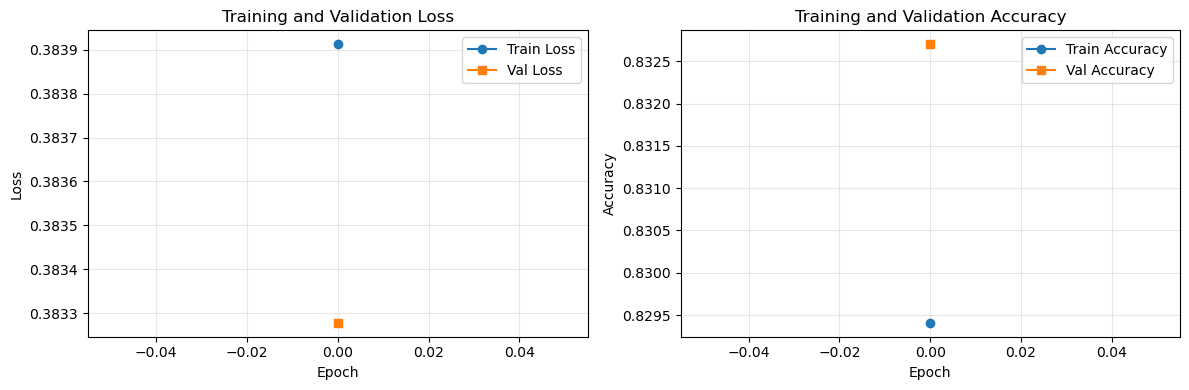

✓ Plot saved: C:\Users\Tommaso\Documents\MEGAR2D2\Documenti\SUPSI\BACHELOR\3_anno_bech\primaverile\M-P6203E-DataProjects-Hackaton3_P1\notebooks\tmp\plots\training_history.png
Best validation loss: 0.3833
Training completed at epoch: 1


In [ ]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'], label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(history['train_acc'], label='Train Accuracy', marker='o')
ax2.plot(history['val_acc'], label='Val Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save plots
save_plot(fig, "training_history.png", "Training History")

print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Training completed at epoch: {len(history['train_loss'])}")

## 10. Evaluation on Test Set


TEST SET EVALUATION

Classification Report:

              precision    recall  f1-score   support

           0     0.7692    0.8087    0.7885    198189
           1     0.7983    0.7574    0.7773    198191

    accuracy                         0.7830    396380
   macro avg     0.7838    0.7830    0.7829    396380
weighted avg     0.7838    0.7830    0.7829    396380



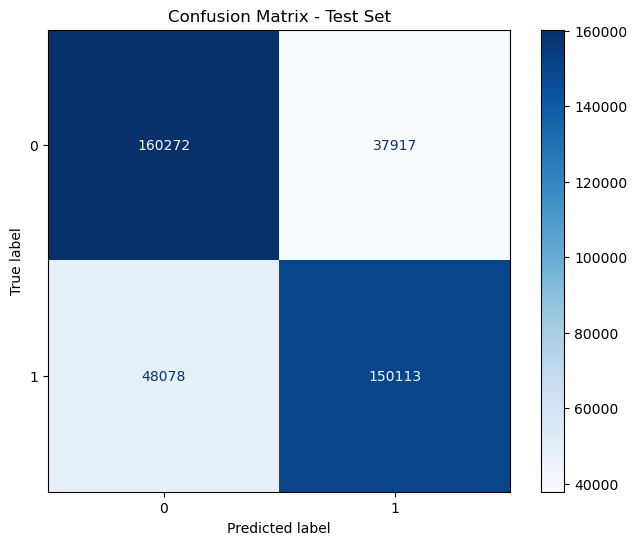

✓ Plot saved: C:\Users\Tommaso\Documents\MEGAR2D2\Documenti\SUPSI\BACHELOR\3_anno_bech\primaverile\M-P6203E-DataProjects-Hackaton3_P1\notebooks\tmp\plots\confusion_matrix.png
✓ Test results saved: C:\Users\Tommaso\Documents\MEGAR2D2\Documenti\SUPSI\BACHELOR\3_anno_bech\primaverile\M-P6203E-DataProjects-Hackaton3_P1\notebooks\tmp\test_results.json


In [ ]:
# Evaluate on test set
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        predictions = torch.argmax(logits, dim=1)
        
        all_preds.extend(predictions.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())

y_pred = np.array(all_preds)
y_test_array = np.array(all_targets)

print("\n" + "="*60)
print("TEST SET EVALUATION")
print("="*60)
print(f"\nClassification Report:\n")
print(classification_report(y_test_array, y_pred, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test_array, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
disp.plot(cmap="Blues", ax=ax_cm)
ax_cm.set_title("Confusion Matrix - Test Set")
plt.show()

# Save confusion matrix plot
save_plot(fig_cm, "confusion_matrix.png", "Confusion Matrix")

# Save test predictions
test_results = {
    'predictions': y_pred.tolist(),
    'true_labels': y_test_array.tolist(),
    'confusion_matrix': cm.tolist()
}

test_results_path = TMP_DIR / "test_results.json"
with open(test_results_path, 'w') as f:
    json.dump(test_results, f, indent=2)
print(f"✓ Test results saved: {test_results_path}")

## 11. Model Comparison Summary

In [ ]:
# Summary of results
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test_array, y_pred)
precision = precision_score(y_test_array, y_pred, average='weighted')
recall = recall_score(y_test_array, y_pred, average='weighted')
f1 = f1_score(y_test_array, y_pred, average='weighted')

print("\n" + "="*60)
print("TRANSFORMER MODEL SUMMARY")
print("="*60)
print(f"Model: Transformer Classifier")
print(f"Input Dimension: {INPUT_DIM}")
print(f"Model Dimension (d_model): {D_MODEL}")
print(f"Attention Heads: {NHEAD}")
print(f"Transformer Layers: {NUM_LAYERS}")
print(f"Total Parameters: {total_params:,}")
print(f"\nTest Metrics:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"\nTraining Info:")
print(f"  Epochs Trained: {len(history['train_loss'])}")
print(f"  Best Val Loss: {best_val_loss:.4f}")
print(f"  Final Train Loss: {history['train_loss'][-1]:.4f}")
print(f"  Final Val Loss: {history['val_loss'][-1]:.4f}")
print("="*60)

# Save final summary
final_summary = {
    "model_info": {
        "name": "Transformer Classifier",
        "input_dim": INPUT_DIM,
        "d_model": D_MODEL,
        "nhead": NHEAD,
        "num_layers": NUM_LAYERS,
        "total_parameters": int(total_params)
    },
    "test_metrics": {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1)
    },
    "training_info": {
        "epochs_trained": len(history['train_loss']),
        "best_val_loss": float(best_val_loss),
        "final_train_loss": float(history['train_loss'][-1]),
        "final_val_loss": float(history['val_loss'][-1])
    }
}

summary_path = TMP_DIR / "model_summary.json"
with open(summary_path, 'w') as f:
    json.dump(final_summary, f, indent=2)
print(f"✓ Model summary saved: {summary_path}")


TRANSFORMER MODEL SUMMARY
Model: Transformer Classifier
Input Dimension: 256
Model Dimension (d_model): 128
Attention Heads: 4
Transformer Layers: 2
Total Parameters: 429,698

Test Metrics:
  Accuracy:  0.7830
  Precision: 0.7838
  Recall:    0.7830
  F1-Score:  0.7829

Training Info:
  Epochs Trained: 1
  Best Val Loss: 0.3833
  Final Train Loss: 0.3839
  Final Val Loss: 0.3833
✓ Model summary saved: C:\Users\Tommaso\Documents\MEGAR2D2\Documenti\SUPSI\BACHELOR\3_anno_bech\primaverile\M-P6203E-DataProjects-Hackaton3_P1\notebooks\tmp\model_summary.json


## 12. Save Model Artifact

In [ ]:
# Save model using the project's model saver utility
try:
    split_name = "predefined_train_validation_test"
    
    # Prepare model info for saving
    model_config = {
        "input_dim": INPUT_DIM,
        "d_model": D_MODEL,
        "nhead": NHEAD,
        "num_layers": NUM_LAYERS,
        "dim_feedforward": DIM_FEEDFORWARD,
        "dropout": DROPOUT,
        "total_parameters": int(total_params),
    }
    
    summary = {
        "scoring": "f1_weighted",
        "test_accuracy": float(accuracy),
        "test_f1": float(f1),
        "test_precision": float(precision),
        "test_recall": float(recall),
        "epochs_trained": len(history['train_loss']),
        "best_val_loss": float(best_val_loss),
    }
    
    model_path, summary_path = save_model_artifact(
        model,
        df_name=df_name,
        model_family="transformer",
        model_name=model_name,
        split_name=split_name,
        params=model_config,
        summary=summary,
        force=False,
    )
    
    print("✓ Model saved successfully using project utility")
    print(f"  Model path: {model_path}")
    print(f"  Summary path: {summary_path}")

except Exception as e:
    print(f"⚠ Could not save using project utility: {e}")
    print("Saving model state dict directly...")
    
    # Fallback: save model state directly
    save_dir = TMP_DIR / "models"
    save_dir.mkdir(exist_ok=True)
    
    model_path = save_dir / f"{model_name}_final.pt"
    torch.save({
        'model_state_dict': model.state_dict(),
        'model_config': model_config,
        'training_summary': summary,
        'scaler': scaler
    }, model_path)
    print(f"  ✓ Model saved to: {model_path}")

✓ Model saved successfully using project utility
  Model path: C:\Users\Tommaso\miniconda3\envs\hack_03\Lib\site-packages\Models\textual_embeddings_64\transformer\transformer_classifier\predefined_train_validation_test\transformer_clas__6469400b8777.joblib
  Summary path: C:\Users\Tommaso\miniconda3\envs\hack_03\Lib\site-packages\Models\textual_embeddings_64\transformer\transformer_classifier\predefined_train_validation_test\summary__transformer_clas__20260425T124227.json


## 13. Additional Analysis: Prediction Confidence

Prediction Confidence Statistics:
  Mean confidence: 0.8210
  Median confidence: 0.8613
  Min confidence: 0.5000
  Max confidence: 0.9915
  Std confidence: 0.1469


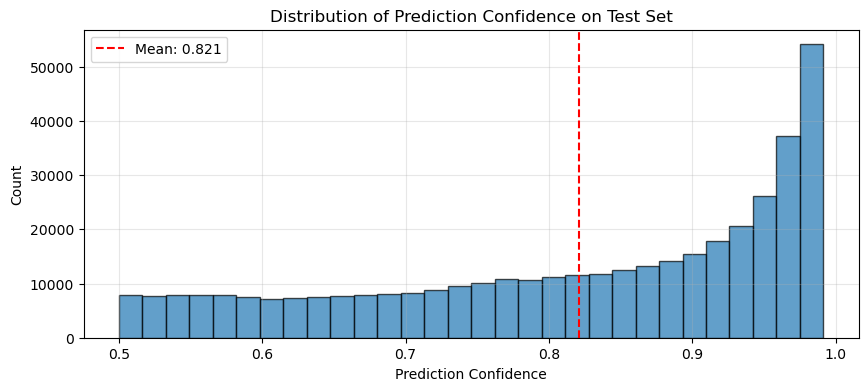

✓ Plot saved: C:\Users\Tommaso\Documents\MEGAR2D2\Documenti\SUPSI\BACHELOR\3_anno_bech\primaverile\M-P6203E-DataProjects-Hackaton3_P1\notebooks\tmp\plots\prediction_confidence.png
✓ Confidence statistics saved: C:\Users\Tommaso\Documents\MEGAR2D2\Documenti\SUPSI\BACHELOR\3_anno_bech\primaverile\M-P6203E-DataProjects-Hackaton3_P1\notebooks\tmp\confidence_stats.json


In [ ]:
# Analyze prediction confidence
model.eval()
all_logits = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.softmax(logits, dim=1)
        all_logits.append(probs.cpu().numpy())

all_probs = np.vstack(all_logits)
confidence = np.max(all_probs, axis=1)

print("Prediction Confidence Statistics:")
print(f"  Mean confidence: {confidence.mean():.4f}")
print(f"  Median confidence: {np.median(confidence):.4f}")
print(f"  Min confidence: {confidence.min():.4f}")
print(f"  Max confidence: {confidence.max():.4f}")
print(f"  Std confidence: {confidence.std():.4f}")

# Plot confidence distribution
fig_conf, ax_conf = plt.subplots(figsize=(10, 4))
ax_conf.hist(confidence, bins=30, edgecolor='black', alpha=0.7)
ax_conf.set_xlabel('Prediction Confidence')
ax_conf.set_ylabel('Count')
ax_conf.set_title('Distribution of Prediction Confidence on Test Set')
ax_conf.axvline(confidence.mean(), color='r', linestyle='--', label=f'Mean: {confidence.mean():.3f}')
ax_conf.legend()
ax_conf.grid(True, alpha=0.3)
plt.show()

# Save confidence plot
save_plot(fig_conf, "prediction_confidence.png", "Prediction Confidence Distribution")

# Save confidence statistics
confidence_stats = {
    'mean': float(confidence.mean()),
    'median': float(np.median(confidence)),
    'min': float(confidence.min()),
    'max': float(confidence.max()),
    'std': float(confidence.std())
}

confidence_path = TMP_DIR / "confidence_stats.json"
with open(confidence_path, 'w') as f:
    json.dump(confidence_stats, f, indent=2)
print(f"✓ Confidence statistics saved: {confidence_path}")